# ToMATo for Geographic Data Analysis

In [1]:
from pathlib import Path

import contextily as cx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tomato import ToMATo

In [2]:
def find_project_root(start=None):
    path = Path(start or Path.cwd()).resolve()

    for parent in [path, *path.parents]:
        if (parent / ".git").exists():
            return parent

    raise FileNotFoundError("Not inside a Git repository")


PROJECT_ROOT = find_project_root()

## I. Point Clustering: Tokyo Flickr Photo Locations
___

### Import Data

In [3]:
data = pd.read_csv(f"{PROJECT_ROOT}/examples/data/tokyo_photos_xy.csv", index_col=0)
data = data.drop_duplicates()

In [4]:
def plot_geoscatter(
    x,
    y,
    color=None,
    size=None,
    marker=None,
    alpha=None,
    cmap=None,
    noise_color="lightgrey",
    figsize=(9, 9),
):

    fig, ax = plt.subplots(1)
    fig.set_figwidth(figsize[0])
    fig.set_figheight(figsize[1])

    if color is not None and isinstance(color, np.ndarray):
        noise = color == -1
        ax.scatter(
            x[noise], y[noise], c=noise_color, s=size, marker=marker, alpha=alpha
        )
        ax.scatter(
            x[~noise],
            y[~noise],
            c=color[~noise],
            s=size,
            marker=marker,
            cmap=cmap,
            alpha=alpha,
        )

    else:
        ax.scatter(x, y, c=color, s=size, marker=marker, cmap=cmap, alpha=alpha)

    cx.add_basemap(ax=ax, source=cx.providers.CartoDB.Positron)

    ax.set_axis_off()

    return fig


def is_clustered(labels):
    return (labels > -1) - 1

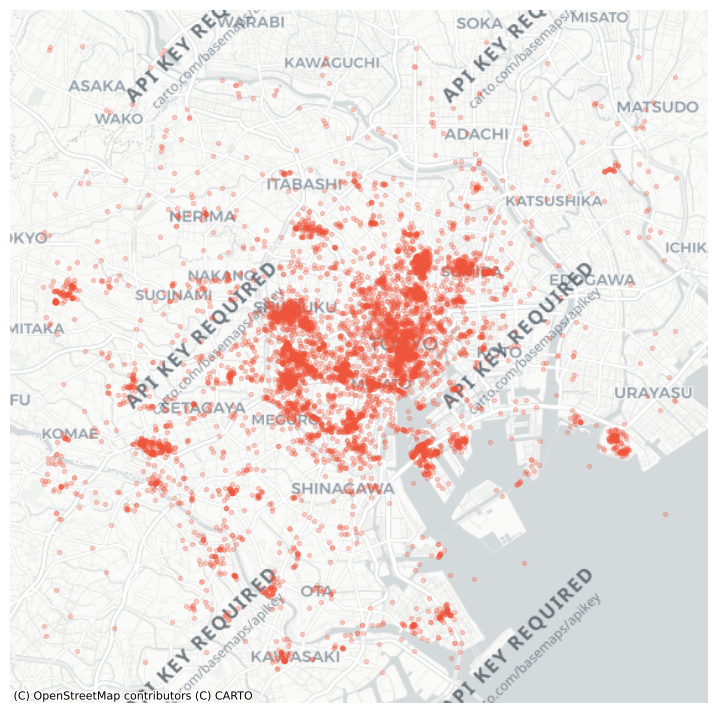

In [5]:
fig = plot_geoscatter(data.x, data.y, color="#ef553b", marker=".", alpha=0.25)

### Cluster Data

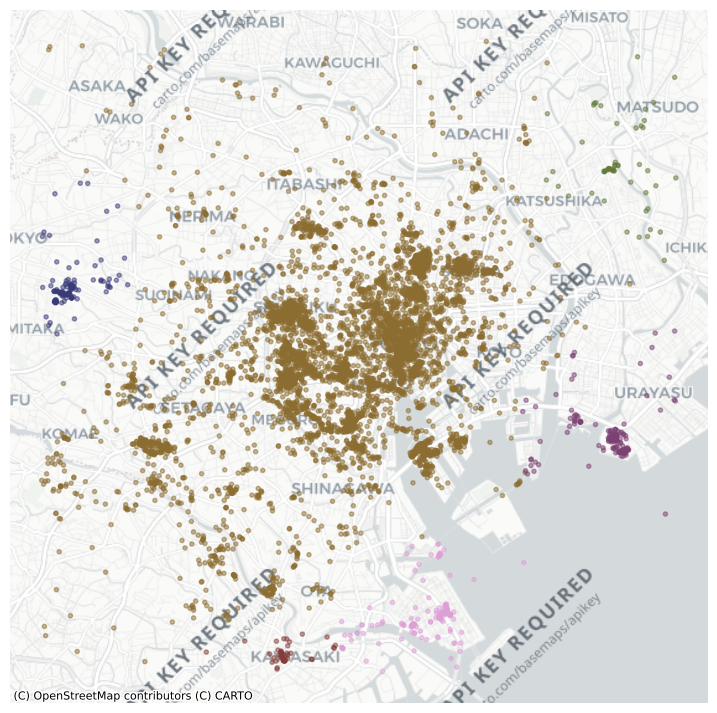

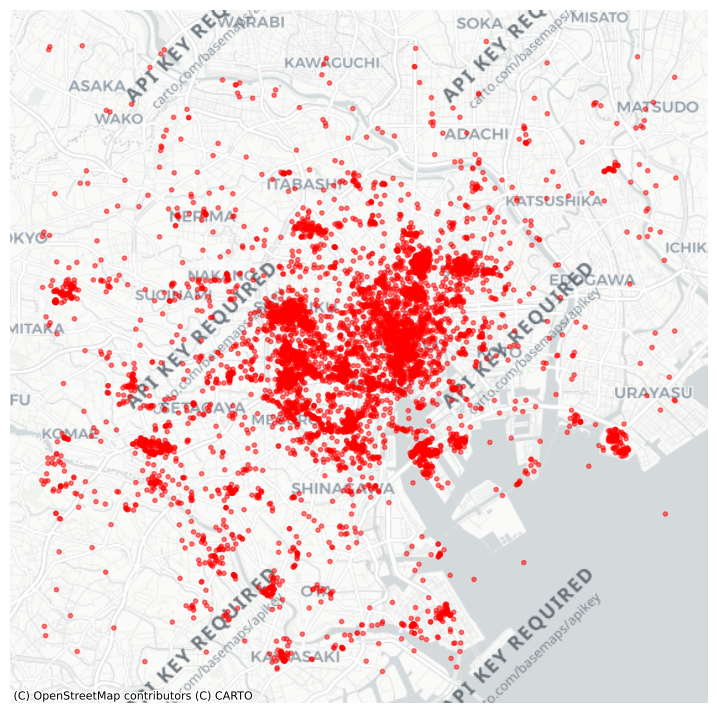

In [6]:
# Default parameters
clf = ToMATo()
labels = clf.fit_predict(data.values)
clustered = is_clustered(labels)

fig = plot_geoscatter(
    data.x, data.y, color=labels, marker=".", alpha=0.5, cmap="tab20b"
)
fig = plot_geoscatter(
    data.x, data.y, color=clustered, marker=".", alpha=0.5, cmap="rainbow_r"
)

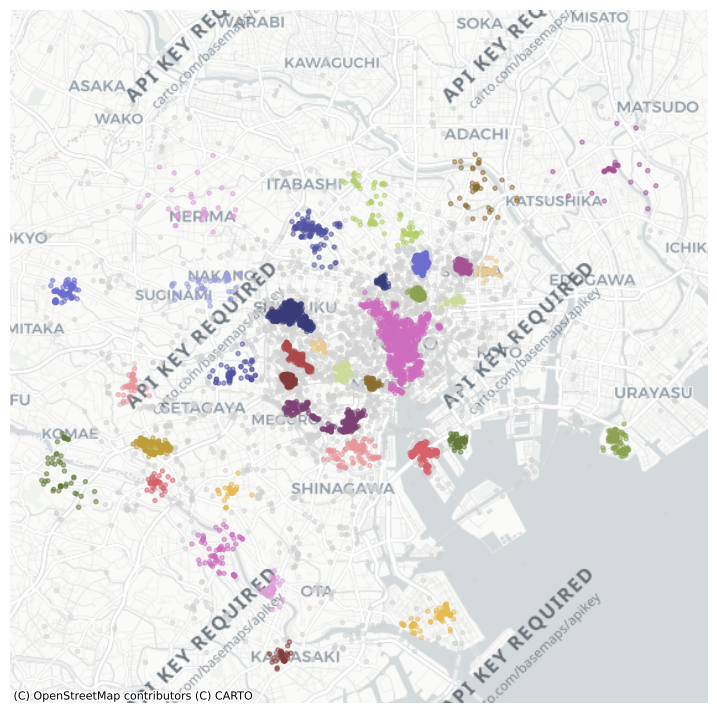

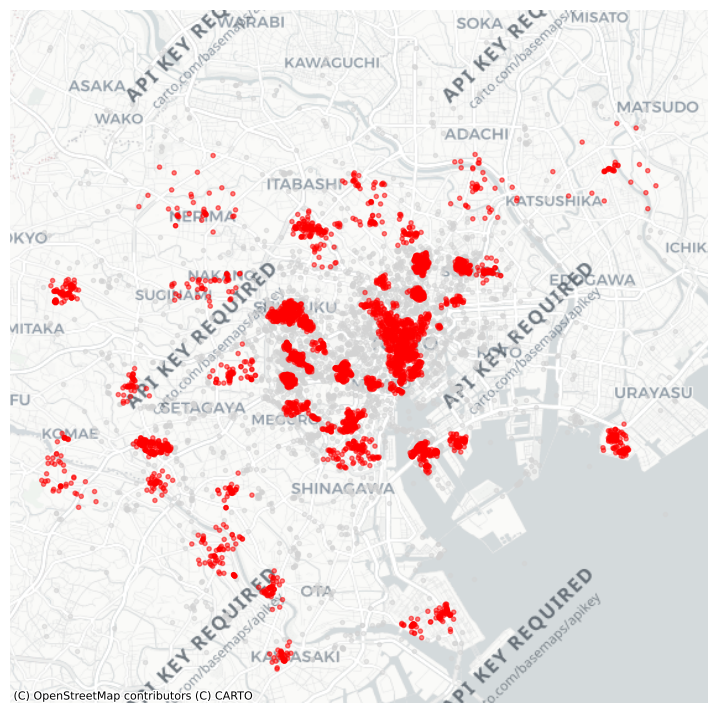

In [7]:
# Selected parameters
clf = ToMATo(n_neighbors=30, min_clusters=35)
labels_full = clf.fit_predict(data.values).copy()
labels = clf.noise_aware_labels(threshold=0.95)
clustered = is_clustered(labels)

fig = plot_geoscatter(
    data.x, data.y, color=labels, marker=".", alpha=0.5, cmap="tab20b"
)
fig = plot_geoscatter(
    data.x, data.y, color=clustered, marker=".", alpha=0.5, cmap="rainbow_r"
)

### Modes as Points of Interest

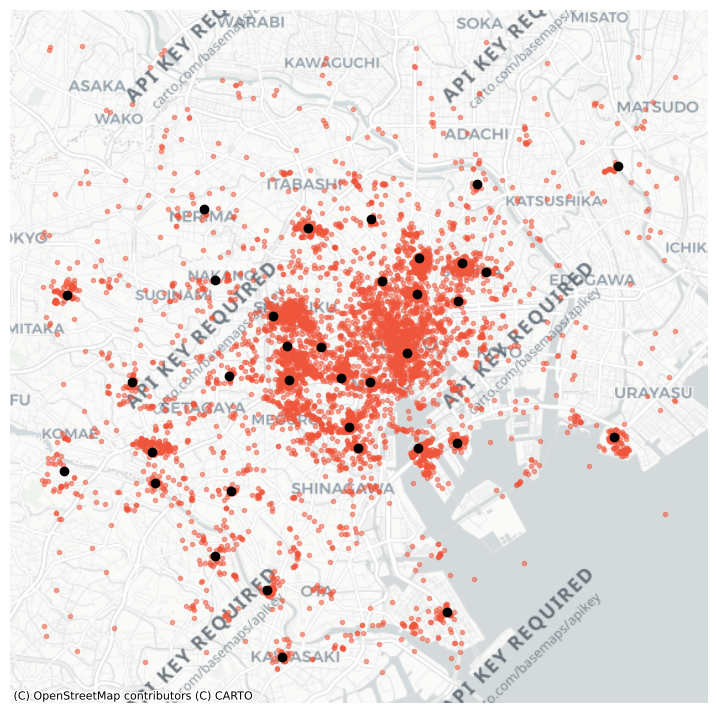

In [8]:
modes_xy = data.iloc[list(clf.modes_.values())]

fig = plot_geoscatter(data.x, data.y, color="#ef553b", marker=".", alpha=0.5)
ax = fig.gca()

ax.scatter(modes_xy.x, modes_xy.y, color="k")

### Clusters as Regions of Interest

In [9]:
import matplotlib.colors as mcolors
from scipy.spatial import Voronoi
from shapely.geometry import Polygon, box
from shapely.ops import unary_union


def bounding_box(X, padding=0.05):
    xmin, ymin = X.min(axis=0)
    xmax, ymax = X.max(axis=0)

    dx = (xmax - xmin) or 1.0
    dy = (ymax - ymin) or 1.0

    xmin -= padding * dx
    xmax += padding * dx
    ymin -= padding * dy
    ymax += padding * dy

    return xmin, xmax, ymin, ymax


def voronoi_finite_polygons(vor, radius):
    """
    Reconstruct finite polygons for every input point's Voronoi cell,
    extending infinite ridges out to `radius`.
    Returns a dict: point_index -> ordered list of vertex coordinates.
    """
    center = vor.points.mean(axis=0)

    point_ridges = {}
    for (p1, p2), (v1, v2) in zip(vor.ridge_points, vor.ridge_vertices):
        point_ridges.setdefault(p1, []).append((p2, v1, v2))
        point_ridges.setdefault(p2, []).append((p1, v1, v2))

    new_regions = {}

    for p, region_idx in enumerate(vor.point_region):
        vertices = vor.regions[region_idx]

        if -1 not in vertices and len(vertices) > 0:
            new_regions[p] = [vor.vertices[v] for v in vertices]
            continue

        finite_verts = [v for v in vertices if v >= 0]
        edges = []

        for neighbor, v1, v2 in point_ridges[p]:
            if v1 == -1 or v2 == -1:
                known_v = v2 if v1 == -1 else v1
                t = vor.points[neighbor] - vor.points[p]
                t /= np.linalg.norm(t)
                n = np.array([-t[1], t[0]])

                midpoint = (vor.points[p] + vor.points[neighbor]) / 2
                direction = np.sign(np.dot(midpoint - center, n)) * n
                if np.allclose(direction, 0):
                    direction = n  # fallback for degenerate sign

                far_point = vor.vertices[known_v] + direction * radius
                edges.append((vor.vertices[known_v], far_point))

        all_pts = list({tuple(vor.vertices[v]) for v in finite_verts})
        for a, b in edges:
            all_pts.append(tuple(b))

        all_pts = np.array(all_pts)
        angles = np.arctan2(
            all_pts[:, 1] - vor.points[p][1], all_pts[:, 0] - vor.points[p][0]
        )
        order = np.argsort(angles)
        new_regions[p] = all_pts[order]

    return new_regions


def voronoi_class_polygons(X, labels, bounds=None, padding=0.05):
    X = np.asarray(X)
    labels = np.asarray(labels)

    if X.ndim != 2 or X.shape[1] != 2:
        raise ValueError("X must have shape (n_samples, 2).")

    vor = Voronoi(X)

    if bounds is None:
        xmin, xmax, ymin, ymax = bounding_box(X, padding=padding)
    else:
        xmin, xmax, ymin, ymax = bounds

    clip_box = box(xmin, ymin, xmax, ymax)
    radius = np.hypot(xmax - xmin, ymax - ymin) * 2

    cell_vertices = voronoi_finite_polygons(vor, radius)

    polygons_by_label = {}

    for p, verts in cell_vertices.items():
        if len(verts) < 3:
            continue
        cell = Polygon(verts).buffer(0)
        clipped = cell.intersection(clip_box)
        if clipped.is_empty:
            continue
        polygons_by_label.setdefault(labels[p], []).append(clipped)

    return {label: unary_union(geoms) for label, geoms in polygons_by_label.items()}


def plot_voronoi_class_polygons(
    ax,
    polygons,
    cmap="viridis",
    alpha=0.5,
    edgecolor="black",
    linewidth=1.0,
    categorical=None,
    vmin=None,
    vmax=None,
    **kwargs
):
    """
    Plot class polygons colored by a colormap on their labels.

    categorical: if None, auto-detected (numeric dtype -> continuous,
        else categorical). Force True/False to override.
    """
    labels = list(polygons.keys())
    cmap = plt.get_cmap(cmap)

    if categorical is None:
        categorical = not np.issubdtype(np.array(labels).dtype, np.number)

    if categorical:
        sorted_labels = sorted(labels, key=str)
        color_map = {
            lab: cmap(i / max(len(sorted_labels) - 1, 1))
            for i, lab in enumerate(sorted_labels)
        }
        norm = None
    else:
        vmin = vmin if vmin is not None else min(labels)
        vmax = vmax if vmax is not None else max(labels)
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        color_map = {lab: cmap(norm(lab)) for lab in labels}

    for label, geom in polygons.items():
        color = color_map[label]
        polys = geom.geoms if geom.geom_type == "MultiPolygon" else [geom]

        for poly in polys:
            x, y = poly.exterior.xy
            ax.fill(
                x,
                y,
                color=color,
                alpha=alpha,
                edgecolor=edgecolor,
                linewidth=linewidth,
                **kwargs
            )
            for interior in poly.interiors:
                xi, yi = interior.xy
                ax.fill(xi, yi, color="white")

    return ax

In [10]:
dense_data = data.loc[labels != -1]
dense_labels = labels[labels != -1]

bbox = bounding_box(data.values)
polygons = voronoi_class_polygons(dense_data, dense_labels, bounds=bbox)

<Axes: >

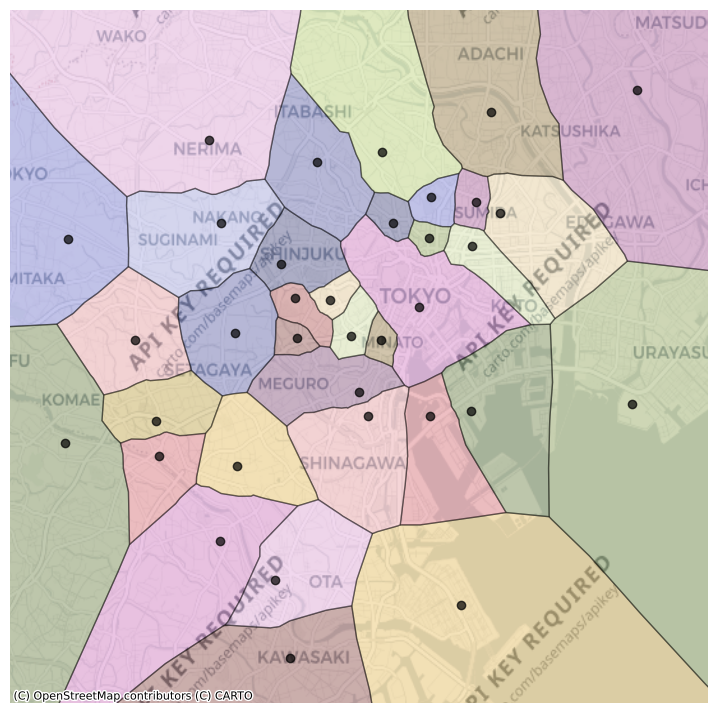

In [11]:
fig = plot_geoscatter(
    dense_data.x, dense_data.y, color=dense_labels, marker=".", alpha=0.0, cmap="tab20b"
)
ax = fig.gca()

modes_xy = data.iloc[list(clf.modes_.values())]
ax.scatter(modes_xy.x, modes_xy.y, c="k", alpha=0.7)

plot_voronoi_class_polygons(ax, polygons, cmap="tab20b", alpha=0.4, zorder=0)

## II. Regionalization: Vector & Raster Clustering
___

In [12]:
import geopandas as gpd
import numpy as np
from libpysal.weights import KNN
from sklearn.preprocessing import RobustScaler, QuantileTransformer

from tomato.regionalization.geotomato_ import GeoToMATo

### Ohio Census Tracts

In [13]:
def shuffle_labels(labels, random_state=None):
    labels = np.asarray(labels)
    unique = np.unique(labels)

    rng = np.random.default_rng(random_state)
    shuffled = rng.permutation(unique)

    mapping = dict(zip(unique, shuffled))

    return np.array([mapping[label] for label in labels], dtype=labels.dtype)


def normalize_attributes(
    gdf: gpd.GeoDataFrame, attributes: list[str]
) -> gpd.GeoDataFrame:
    gdf_normalized = gdf.copy(deep=True)
    X = gdf_normalized[attributes].values
    gdf_normalized[attributes] = RobustScaler().fit_transform(X)
    return gdf_normalized


def knn_graph(gdf, k: int = 25):
    w = KNN.from_dataframe(gdf, k=k)

    graph = w.sparse.tocsr().astype(float)
    graph = graph.maximum(graph.T)
    graph.setdiag(0)
    graph.eliminate_zeros()

    return graph

In [14]:
DROP_COLS = ["geoid", "population", "geometry"]

In [15]:
census = gpd.read_parquet(f"{PROJECT_ROOT}/examples/data/ohio_census_2025.parquet")
census = census.to_crs("EPSG:3857")

In [16]:
attributes = [c for c in census.columns if c not in DROP_COLS and "pct" in c]
X = QuantileTransformer().fit_transform(census[attributes].values)
graph = knn_graph(census, k=25)

In [17]:
clf = GeoToMATo(n_hops=1, n_clusters=20, mass_fraction=0.9)
clf.fit(graph, X)

(-9466095.757609973, -8939358.643853994, 4610484.45863818, 5184449.036033172)

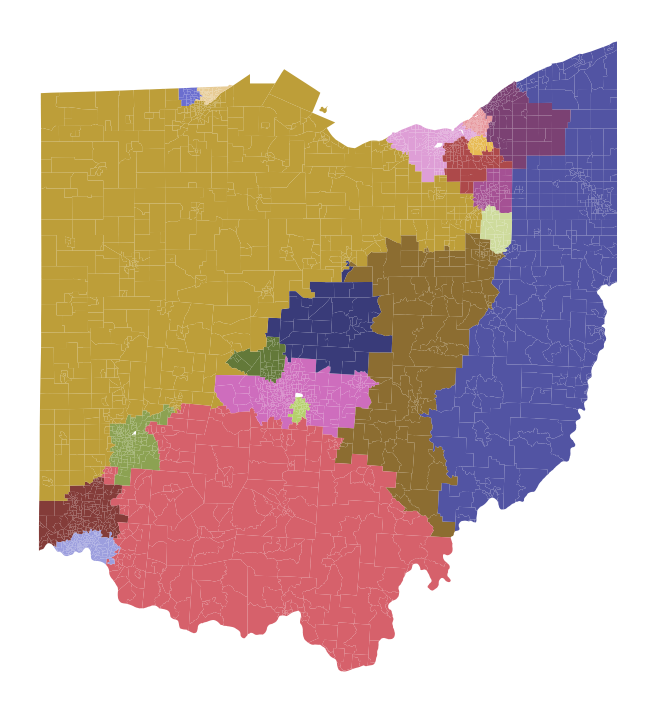

In [22]:
census_clf = census.copy()
census_clf["label"] = shuffle_labels(clf.labels_, random_state=0)
census_clf.plot("label", cmap="tab20b")

plt.gcf().set_figwidth(9)
plt.gcf().set_figheight(9)
plt.axis("off")

### Salinas Valley, CA Hyperspectral

In [19]:
from salinas_test import run_salinas_tests

graph    method  target_k  k  ARI_class  ARI_contig  homog_contig  compl_contig         SSD  frag  seconds
Queen GeoToMATo        32 32      0.883       0.892         0.879         0.976 1020695.106 1.000    0.374
Queen GeoToMATo        32 32      0.667       0.629         0.797         0.876  453047.201 1.000    0.948
  KNN GeoToMATo        32 32      0.912       0.954         0.932         0.973 1021518.717 1.031    0.533
  KNN GeoToMATo        32 32      0.602       0.540         0.768         0.832  370351.629 6.562    2.032


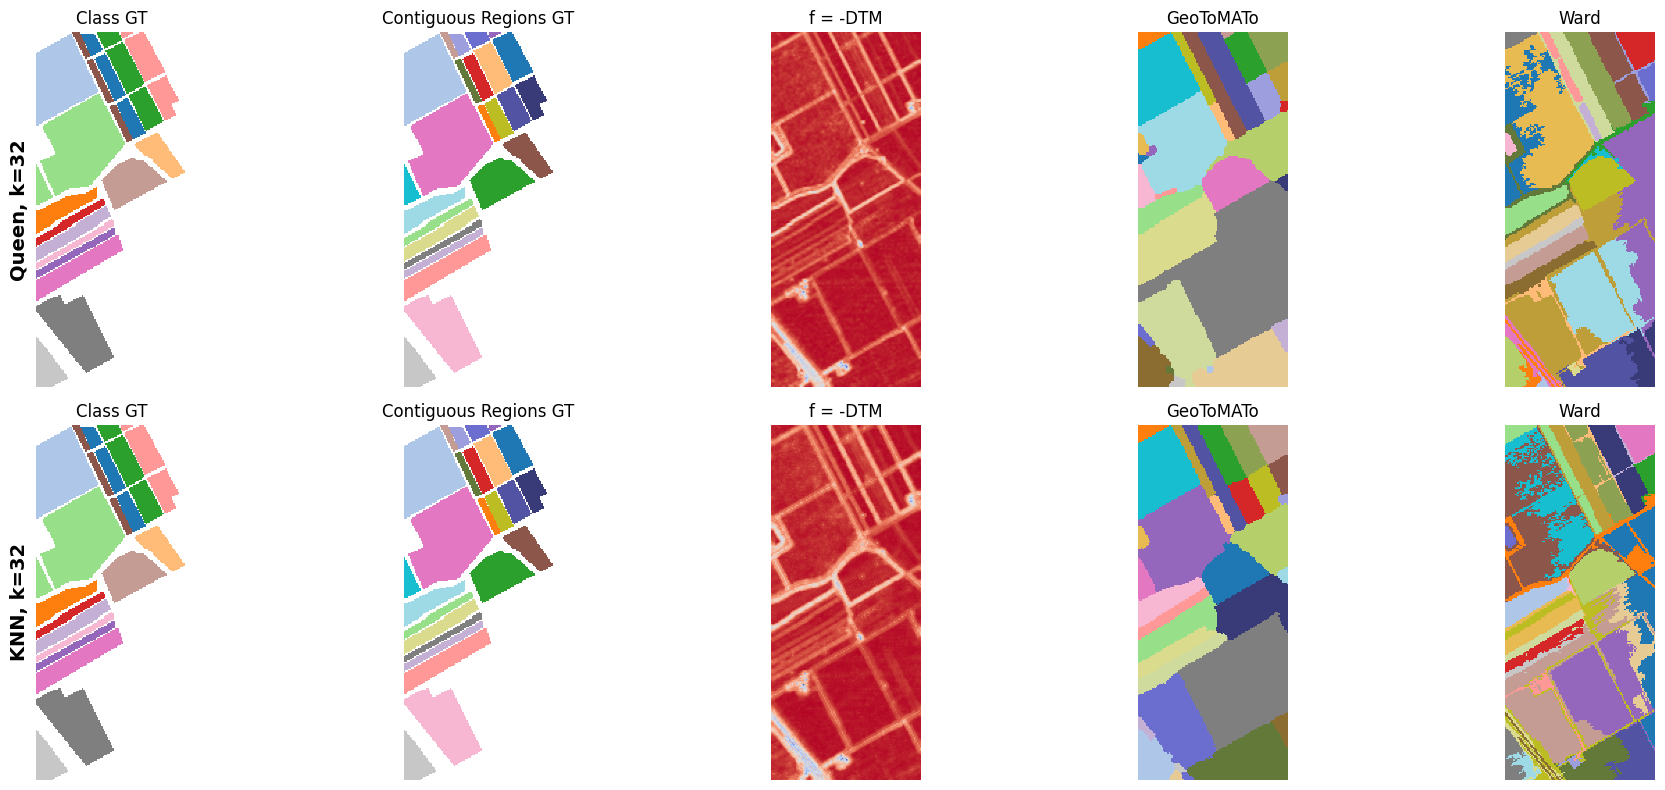

In [20]:
res, fig = run_salinas_tests(
    data_path="data/Salinas_corrected.mat",
    gt_path="data/Salinas_gt.mat",
    block_size=2,
    n_clusters=32,
    n_hops=1,
    mass_fraction=1.0,
    noise_threshold=0.0,
)

graph    method  target_k  k  ARI_class  ARI_contig  homog_contig  compl_contig         SSD  frag  seconds
Queen GeoToMATo        32 33      0.812       0.827         0.838         0.905 1251085.048 3.394    0.403
Queen GeoToMATo        32 32      0.667       0.629         0.797         0.876  453047.201 1.000    1.030
  KNN GeoToMATo        32 33      0.843       0.888         0.891         0.909 1233167.238 3.121    0.583
  KNN GeoToMATo        32 32      0.602       0.540         0.768         0.832  370351.629 6.562    2.063


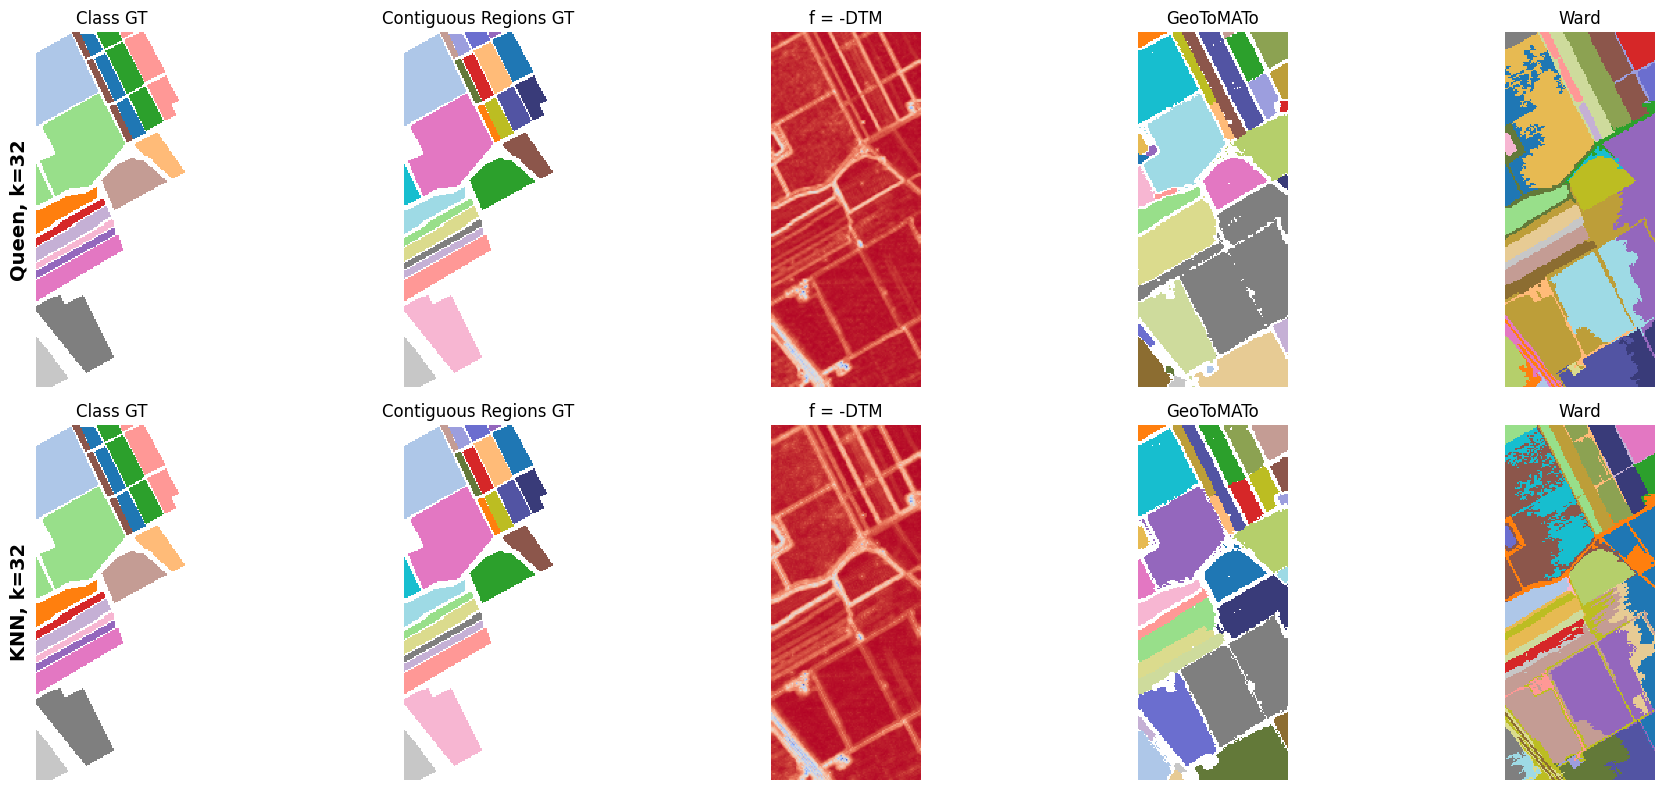

In [21]:
res, fig = run_salinas_tests(
    data_path="data/Salinas_corrected.mat",
    gt_path="data/Salinas_gt.mat",
    block_size=2,
    n_clusters=32,
    n_hops=1,
    mass_fraction=1.0,
    noise_threshold=0.5,
)